# LTN Cross-Task Consistency — Results Dashboard

Loads the per-seed test-set results produced by `TRAIN_EVAL_EQUAL_WEIGHTING.py`
(via `aggregate_results.py`), and builds comparison plots across configurations.

**Run this notebook from the project root** (same folder as `aggregate_results.py`),
so the import below works, and so `--log_name` resolves to the right results folder.

Re-run this notebook any time to refresh the plots as more configs/seeds finish —
nothing here needs to be edited except the `LOG_NAME` / `TRAINING_MODE` cell below.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import aggregate_results as ar

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

## Configuration

Edit these two lines to match your run.

In [3]:
LOG_NAME = "BPIC_19"
TRAINING_MODE = None  # only needed if a run directory has more than one results pickle

per_seed_df, grouped_df = ar.aggregate(LOG_NAME, TRAINING_MODE)
print(f"Found {len(per_seed_df)} runs across {per_seed_df['config'].nunique()} configuration(s).")

Found 14 runs across 9 configuration(s).


## Raw per-seed results

One row per (config, seed) — useful for spotting an outlier seed before trusting the aggregate.

In [4]:
per_seed_df.sort_values(['config', 'seed']).reset_index(drop=True)

,MAE RRT minutes,DL sim,mean_abs_gap_IB,mean_abs_gap_CB,mean_signed_gap_IB,mean_signed_gap_CB,signed_bias_rrt_IB,signed_bias_rrt_CB,signed_bias_ttne_sum_IB,signed_bias_ttne_sum_CB,error_correlation_IB,config,seed
0,24454.525579,0.855084,535282.31250,761108.717677,-463315.84375,-695031.572853,347004.25000,678197.206248,-116311.710938,-16834.473921,0.840262,SUTRAN_DA_results_subset_0.15,3
1,24239.489495,0.855795,537250.50000,768122.182332,-492867.84375,-723050.412497,348889.96875,678936.942547,-143978.015625,-44113.616803,0.837672,SUTRAN_DA_results_subset_0.15,17
2,24559.419833,0.854946,539061.18750,766459.345865,-468195.62500,-698747.244197,355891.62500,683190.912011,-112304.125000,-15556.555291,0.834510,SUTRAN_DA_results_subset_0.15_balanced,3
3,24519.168346,0.854720,506063.59375,730862.806813,-416591.18750,-650201.863207,330628.18750,662540.923131,-85963.015625,12339.006266,0.844382,SUTRAN_DA_results_subset_0.15_ltn_0.01,3
4,24170.927615,0.855674,523642.00000,752630.285059,-477235.31250,-706097.297679,330920.96875,660409.329450,-146314.437500,-45688.084017,0.842643,SUTRAN_DA_results_subset_0.15_ltn_0.01,17
5,24248.874580,0.854790,493611.65625,716446.376136,-414368.40625,-643283.153120,329243.62500,656790.852705,-85124.859375,13507.606390,0.845175,SUTRAN_DA_results_subset_0.15_ltn_0.05,3
6,24235.583938,0.855811,511185.28125,740452.673903,-464607.71875,-693611.790663,347957.46875,677300.584944,-116650.328125,-16311.267849,0.842923,SUTRAN_DA_results_subset_0.15_ltn_0.05,17
7,24563.366058,0.854375,483375.03125,714859.361398,-394124.37500,-634344.232283,371856.90625,704772.089313,-22267.542969,70427.766658,0.846044,SUTRAN_DA_results_subset_0.15_ltn_0.1,3
8,24033.254093,0.855794,464038.87500,686920.410202,-412334.75000,-635259.470126,296199.50000,619786.053835,-116135.359375,-15473.588562,0.854111,SUTRAN_DA_results_subset_0.15_ltn_0.1,17
9,24467.308634,0.855462,481763.84375,704726.135381,-425015.12500,-652201.785544,376559.59375,702186.649722,-48455.625000,49984.773806,0.846035,SUTRAN_DA_results_subset_0.15_ltn_0.1_balanced,3


## Aggregated summary (mean ± std across seeds)

Configs with only 1 seed so far will show `std = NaN` — expected while runs are still in progress;
error bars are simply omitted for those in the plots below.

In [5]:
ar.format_summary_table(grouped_df)
print(ar.format_summary_table(grouped_df))

| config                                            |   n_seeds | MAE RRT minutes       | DL sim          | mean_abs_gap_IB          | mean_abs_gap_CB          | mean_signed_gap_IB        | mean_signed_gap_CB        | signed_bias_rrt_IB       | signed_bias_rrt_CB       | signed_bias_ttne_sum_IB   | signed_bias_ttne_sum_CB   | error_correlation_IB   |
|:--------------------------------------------------|----------:|:----------------------|:----------------|:-------------------------|:-------------------------|:--------------------------|:--------------------------|:-------------------------|:-------------------------|:--------------------------|:--------------------------|:-----------------------|
| SUTRAN_DA_results_subset_0.15                     |         2 | 24347.0075 ± 152.0535 | 0.8554 ± 0.0005 | 536266.4062 ± 1391.7187  | 764615.4500 ± 4959.2684  | -478091.8438 ± 20896.4196 | -709040.9927 ± 19812.3115 | 347947.1094 ± 1333.4045  | 678567.0744 ± 523.0726   | -130144.8633 ± 19563.0

In [6]:
def bar_with_err(ax, grouped, metric, title, ylabel):
    """Bar chart of a metric's mean per config, with std-across-seeds error bars.
    Configs with a single seed (std is NaN) get a bar with no error bar."""
    means = grouped[f"{metric}_mean"]
    stds = grouped[f"{metric}_std"].fillna(0)
    x = np.arange(len(grouped))
    ax.bar(x, means, yerr=stds, capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(grouped["config"], rotation=45, ha="right", fontsize=8)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="black", linewidth=0.6)

## 1. Task accuracy: did LTN help or hurt the base tasks?

The most basic check — regardless of any consistency effect, neither head should get
meaningfully *worse* under the LTN configs compared to the baseline.

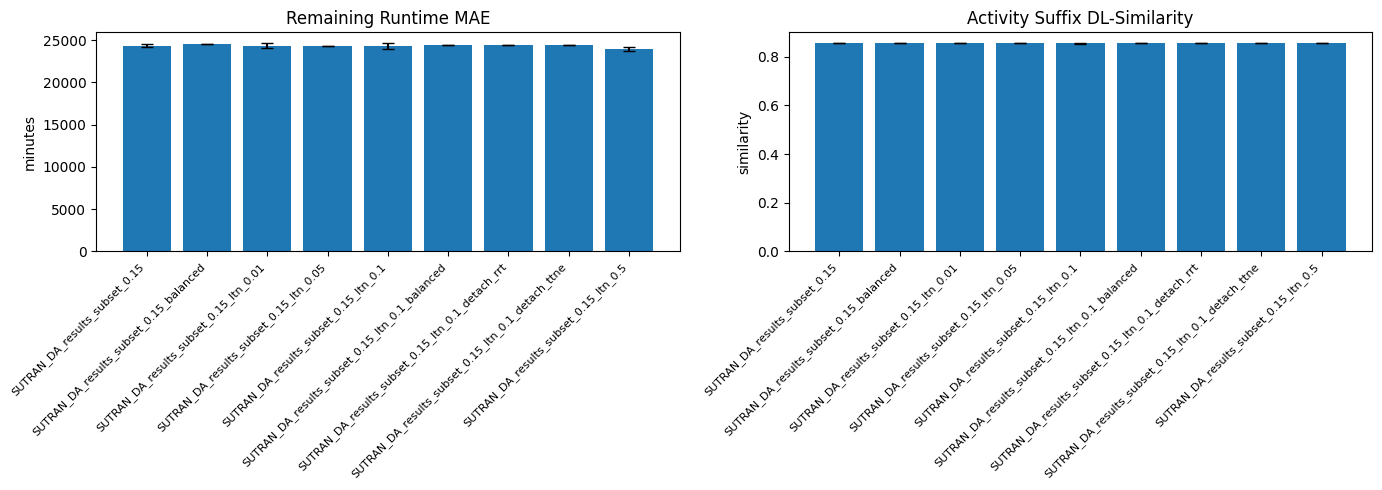

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_with_err(axes[0], grouped_df, "MAE RRT minutes", "Remaining Runtime MAE", "minutes")
bar_with_err(axes[1], grouped_df, "DL sim", "Activity Suffix DL-Similarity", "similarity")
plt.tight_layout()
plt.show()

## 2. Consistency gap: did LTN actually make the two heads more consistent?

`mean_abs_gap` = average |Σ predicted Δt − predicted remaining runtime|, in original units (seconds).
Lower is more consistent. CB (case-based) is the primary number — it weights each original
case equally, matching how the rest of your metrics are computed; IB (instance-based) is shown
alongside as a cross-check.

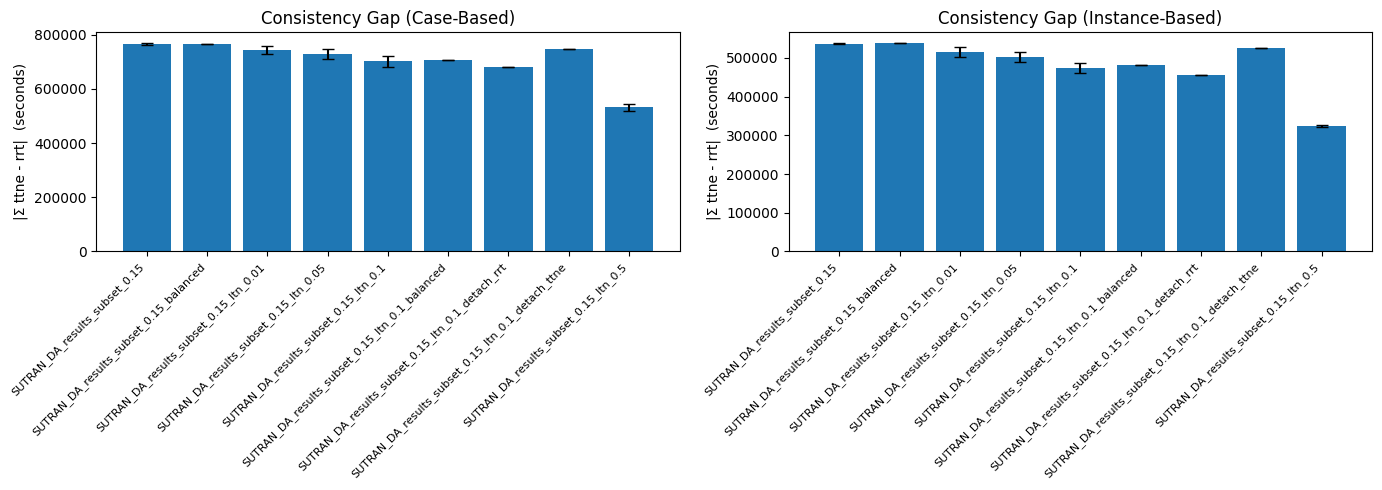

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_with_err(axes[0], grouped_df, "mean_abs_gap_CB", "Consistency Gap (Case-Based)", "|Σ ttne - rrt|  (seconds)")
bar_with_err(axes[1], grouped_df, "mean_abs_gap_IB", "Consistency Gap (Instance-Based)", "|Σ ttne - rrt|  (seconds)")
plt.tight_layout()
plt.show()

## 3. The cheating check: signed bias per head

If both bars for a config shift in the *same direction* away from zero relative to the baseline,
that's the "meeting in the middle" signature — the heads are drifting toward each other rather
than toward the ground truth. If only one bar moves (and its own MAE didn't get worse — check
plot 1 again), that's more likely genuine improvement from that head alone.

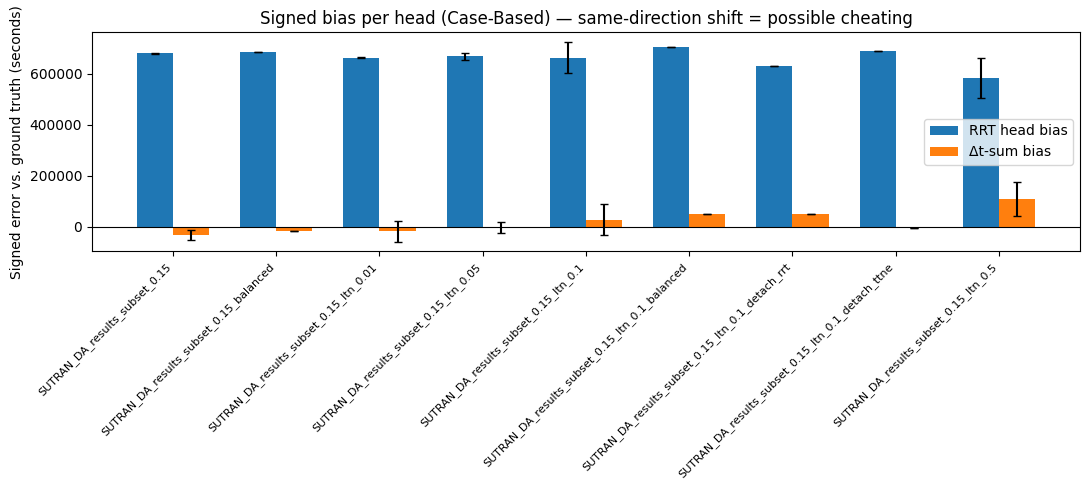

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(grouped_df))
width = 0.35
ax.bar(x - width/2, grouped_df["signed_bias_rrt_CB_mean"], width,
       yerr=grouped_df["signed_bias_rrt_CB_std"].fillna(0), capsize=3, label="RRT head bias")
ax.bar(x + width/2, grouped_df["signed_bias_ttne_sum_CB_mean"], width,
       yerr=grouped_df["signed_bias_ttne_sum_CB_std"].fillna(0), capsize=3, label="Δt-sum bias")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(grouped_df["config"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Signed error vs. ground truth (seconds)")
ax.set_title("Signed bias per head (Case-Based) — same-direction shift = possible cheating")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Error correlation between the two heads

Some baseline correlation (λ=0) is expected — both heads see the same underlying cases,
so harder cases tend to be harder for both. What matters is whether correlation rises
*further* under LTN configs without an accompanying drop in either head's MAE (plot 1) —
that combination would indicate the heads are tracking each other rather than genuinely
improving. Only computed instance-based (no natural case-weighted equivalent for correlation).

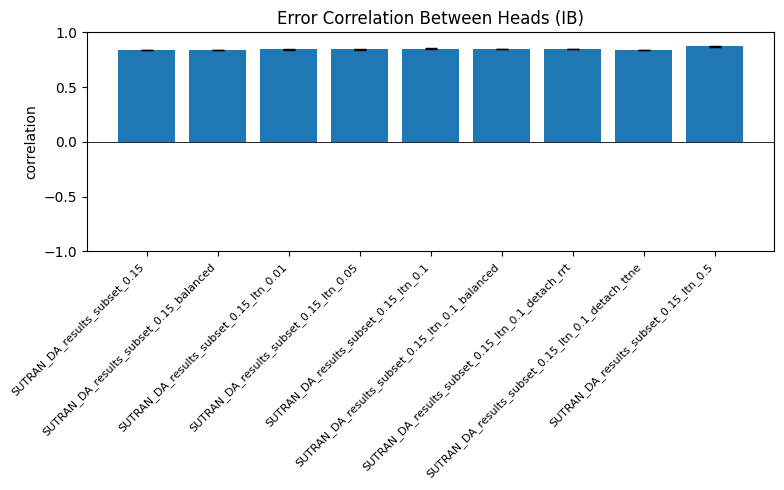

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
bar_with_err(ax, grouped_df, "error_correlation_IB", "Error Correlation Between Heads (IB)", "correlation")
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.show()

## 5. All metrics, side by side (small multiples)

A quick overview grid — useful once more configs are in, to eyeball everything at once
before deciding what to write up in detail.

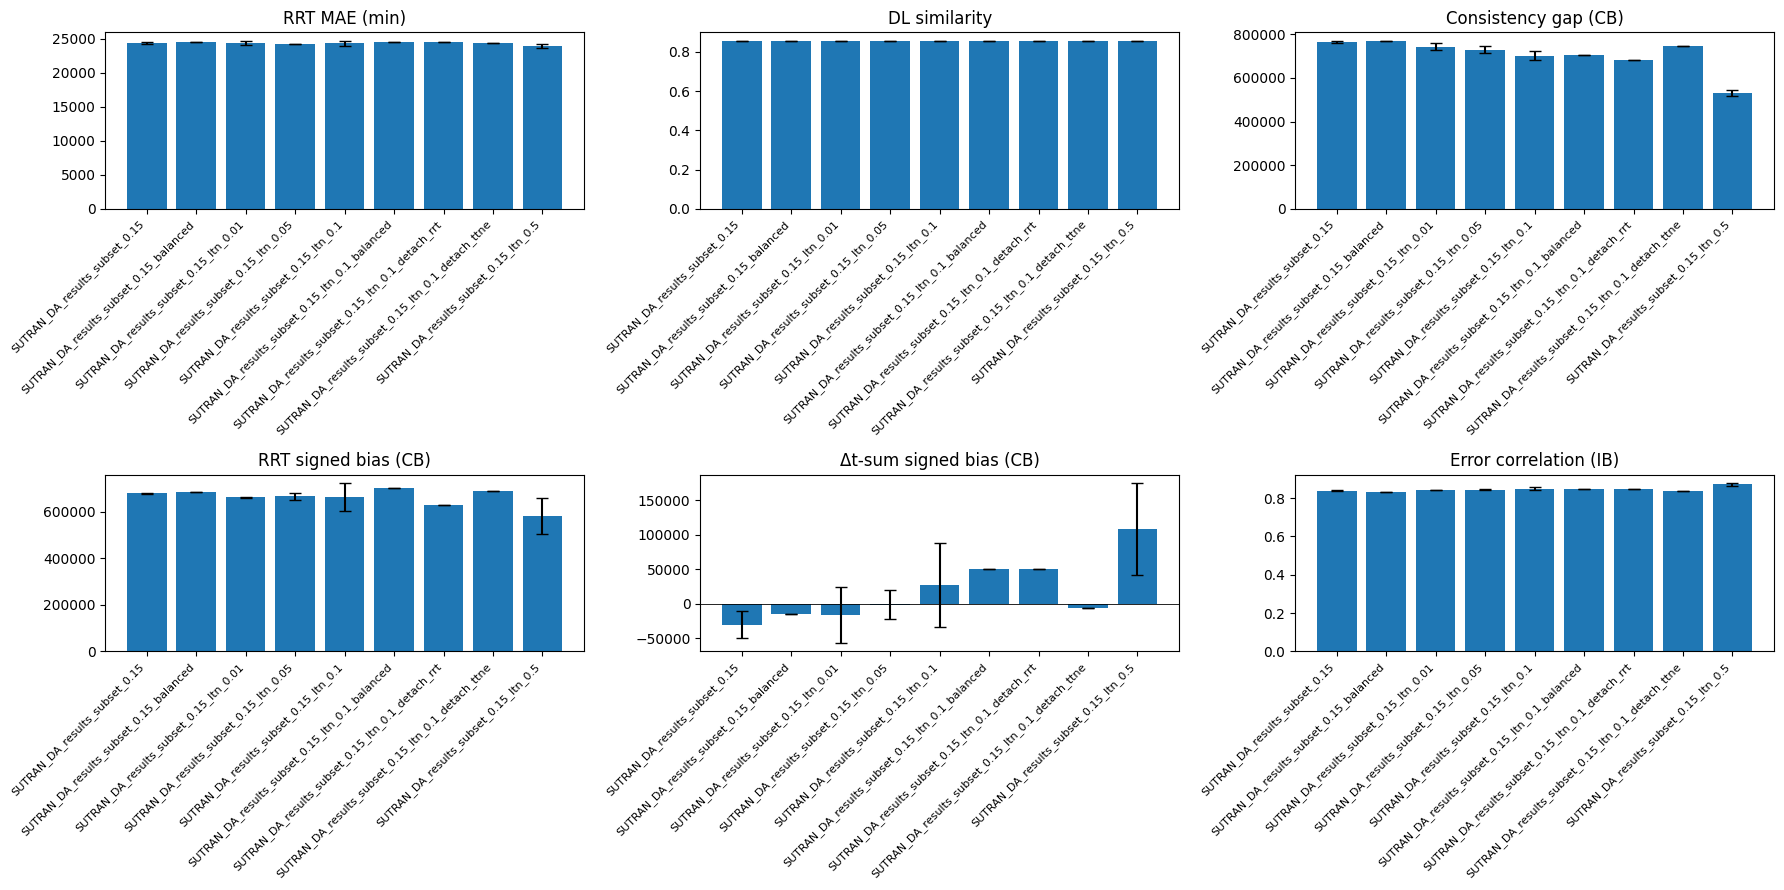

In [11]:
plot_metrics = [
    ("MAE RRT minutes", "RRT MAE (min)"),
    ("DL sim", "DL similarity"),
    ("mean_abs_gap_CB", "Consistency gap (CB)"),
    ("signed_bias_rrt_CB", "RRT signed bias (CB)"),
    ("signed_bias_ttne_sum_CB", "Δt-sum signed bias (CB)"),
    ("error_correlation_IB", "Error correlation (IB)"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, (metric, label) in zip(axes.flat, plot_metrics):
    bar_with_err(ax, grouped_df, metric, label, "")
plt.tight_layout()
plt.show()

## Notes

- Bars with no visible error whisker mean only one seed has completed for that config so far —
  re-run this notebook once more seeds finish; nothing else needs to change.
- If a config folder from a partially-finished run appears with obviously incomplete/odd numbers,
  check `per_seed_df` above to confirm which seed(s) are actually in it before drawing conclusions
  from the aggregated bars.
- All "CB" (case-based) metrics weight each original case equally, matching the paper's own
  metric convention; "IB" (instance-based) is a secondary cross-check and can overweight
  long-suffix cases.